# Machine Learning — Homework 6: Neural Networks and ML Diagnosis

**Course:** Machine Learning · **National University of Kyiv-Mohyla Academy (NaUKMA)**  
**Modules 8–9:** Optimization and Neural Networks · Diagnosing ML Systems (Weeks 8–9) · **Instructor:** Dmytro Kuzmenko

**Meta**

| Field | Value |
|---|---|
| Points | 5 (1.25 per task) |
| Estimated time | 3–4 hours |
| Prerequisites | Modules 1–8; numpy, sklearn; PyTorch basics (this is the only HA where PyTorch is used) |
| Environment | CPU only, deterministic seeds, small models (runtime ≈ 1–2 min) |
| Deadline | (placeholder — set on DistEdu) |

---

## AI Use Disclosure

Fill this in before submitting. Being honest here cannot lower your grade; hiding AI use and being caught can.

- **AI tools used:**
- **Nature of assistance:**
- **Representative prompts or relevant interaction:**
- **What I independently verified or changed:**

---

## Learning Objectives

- Build and train a small multilayer perceptron with a manual minibatch loop, and read train/validation loss curves.
- Choose and justify a learning rate; predict and verify the effect of a decay schedule.
- Demonstrate capacity-driven overfitting and control it with early stopping / weight decay.
- Diagnose bias vs variance from learning curves, and use permutation importance to interpret a model — including its known limitation with correlated features.

---

## Warm-up

Run the setup cell. Everything is seeded: `np.random.seed(42)`, `torch.manual_seed(42)`. The data for Tasks 1–3 is the same two-moons set (400 points, noise 0.2) so experiments are comparable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

np.random.seed(42)
torch.manual_seed(42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
print("Moons: %d train, %d validation points" % (len(X_train), len(y_train == 1)))
print("PyTorch %s, CPU only" % torch.__version__)

Moons: 300 train, 300 validation points
PyTorch 2.10.0, CPU only


In [2]:
def make_mlp(w1=32, w2=16):
    """2 hidden layers [w1, w2] (or 1 hidden layer if w2 is None), ReLU,
    single logit output (to be used with BCEWithLogitsLoss)."""
    if w2 is None:
        return nn.Sequential(
            nn.Linear(2, w1), nn.ReLU(),
            nn.Linear(w1, 1),
        )
    return nn.Sequential(
        nn.Linear(2, w1), nn.ReLU(),
        nn.Linear(w1, w2), nn.ReLU(),
        nn.Linear(w2, 1),
    )

## Guided Exercise

### Task 1: Build a Small MLP and Read Its Loss Curves

**Experiment (A).** Train a small MLP with two hidden layers of 32 and 16 units (ReLU), log-loss, on the moons data — 300 epochs of plain minibatch SGD, batch size 32, learning rate 0.01. Record train and validation loss every epoch.

### Task 1: Build a Small MLP and Read Its Loss Curves

**Experiment (A).** Train a small MLP with two hidden layers of 32 and 16 units (ReLU), log-loss, on the moons data — 300 epochs of plain minibatch SGD, batch size 32, learning rate 0.01. Record train and validation loss every epoch. The helper below also returns the trained model so we can measure accuracy.

In [3]:
def train_mlp(w1, w2, lr, epochs=300, batch_size=32, Xtr=X_train, ytr=y_train,
              Xva=X_val, yva=y_val, weight_decay=0.0, decay_gamma=None,
              early_stop_patience=None, seed=42):
    """Manual minibatch training loop (SGD + BCEWithLogitsLoss).
    Returns (model, hist) where hist holds train/val loss per epoch."""
    torch.manual_seed(seed)
    model = make_mlp(w1, w2)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=decay_gamma) if decay_gamma else None
    loss_fn = nn.BCEWithLogitsLoss()

    Xt = torch.tensor(Xtr, dtype=torch.float32)
    yt = torch.tensor(ytr, dtype=torch.float32).view(-1, 1)
    Xv = torch.tensor(Xva, dtype=torch.float32)
    yv = torch.tensor(yva, dtype=torch.float32).view(-1, 1)

    n = len(Xt)
    hist = {"train": [], "val": []}
    best_val = np.inf
    best_epoch = 0
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            optimizer.zero_grad()
            out = model(Xt[idx])
            loss = loss_fn(out, yt[idx])
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        with torch.no_grad():
            hist["train"].append(loss_fn(model(Xt), yt).item())
            v = loss_fn(model(Xv), yv).item()
            hist["val"].append(v)
        if early_stop_patience is not None:
            if v < best_val - 1e-4:
                best_val = v
                best_epoch = ep
            if ep - best_epoch > early_stop_patience:
                hist["stopped_at"] = best_epoch
                break
    return model, hist

Xv = torch.tensor(X_val, dtype=torch.float32)
model_t1, hist_t1 = train_mlp(32, 16, lr=0.01, epochs=300)
with torch.no_grad():
    preds = (torch.sigmoid(model_t1(Xv)).numpy() > 0.5).astype(int).ravel()
val_acc = (preds == y_val).mean()
print("Train loss: %.4f | val loss: %.4f | best val loss: %.4f | val accuracy: %.4f" %
      (hist_t1["train"][-1], hist_t1["val"][-1], min(hist_t1["val"]), val_acc))

Train loss: 0.2228 | val loss: 0.3124 | best val loss: 0.3118 | val accuracy: 0.8600


**Evidence (C).** Plot both loss curves so convergence and the train/val gap are visible.

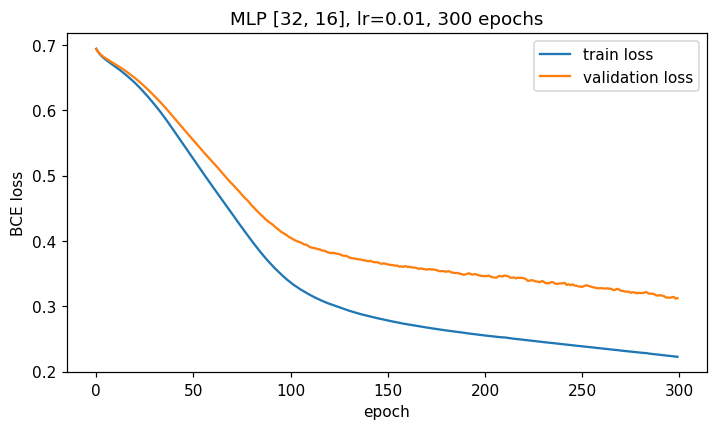

In [4]:
plt.figure(figsize=(7.5, 4))
plt.plot(hist_t1["train"], label="train loss")
plt.plot(hist_t1["val"], label="validation loss")
plt.xlabel("epoch"); plt.ylabel("BCE loss")
plt.title("MLP [32, 16], lr=0.01, 300 epochs")
plt.legend(); plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

Two layers [32,16]:  val loss 0.3124
One layer  [32]:     val loss 0.3566


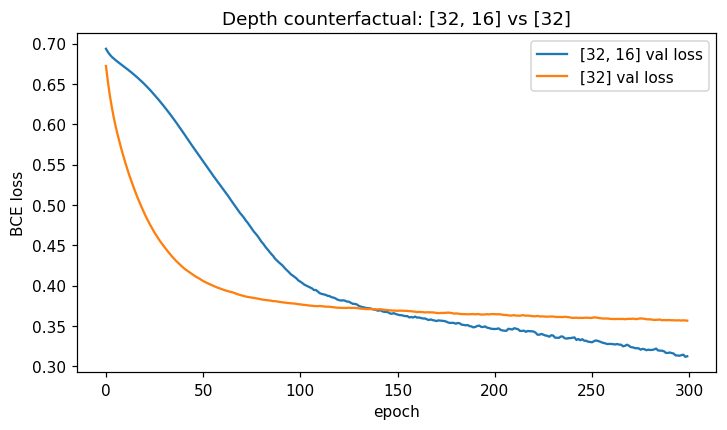

In [5]:
# Counterfactual: single hidden layer [32] instead of [32, 16]
_, hist_1l = train_mlp(32, None, lr=0.01, epochs=300)
print("Two layers [32,16]:  val loss %.4f" % hist_t1["val"][-1])
print("One layer  [32]:     val loss %.4f" % hist_1l["val"][-1])
plt.figure(figsize=(7.5, 4))
plt.plot(hist_t1["val"], label="[32, 16] val loss")
plt.plot(hist_1l["val"], label="[32] val loss")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.legend()
plt.title("Depth counterfactual: [32, 16] vs [32]")
plt.show()

**Your answer:**

### Task 2: Learning Rate — Slow, Steady, and Divergent

**Experiment (A).** Train the same [32, 16] MLP for 300 epochs with three learning rates: 0.001, 0.1, and 1.0. Keep everything else identical (same seeds, same data).

In [6]:
lr_results = {}
for lr in [0.001, 0.1, 1.0]:
    _, h = train_mlp(32, 16, lr=lr, epochs=300)
    lr_results[lr] = h
    print("lr = %-5s | train %.4f | val %.4f | best val %.4f" %
          (lr, h["train"][-1], h["val"][-1], min(h["val"])))

lr = 0.001 | train 0.6122 | val 0.6245 | best val 0.6245


lr = 0.1   | train 0.0663 | val 0.0894 | best val 0.0722


lr = 1.0   | train 0.0482 | val 0.1351 | best val 0.0572


**Evidence (C).** Plot the three validation-loss curves (and, in a second panel, the train-loss curves) on a common axis so the failure modes are comparable.

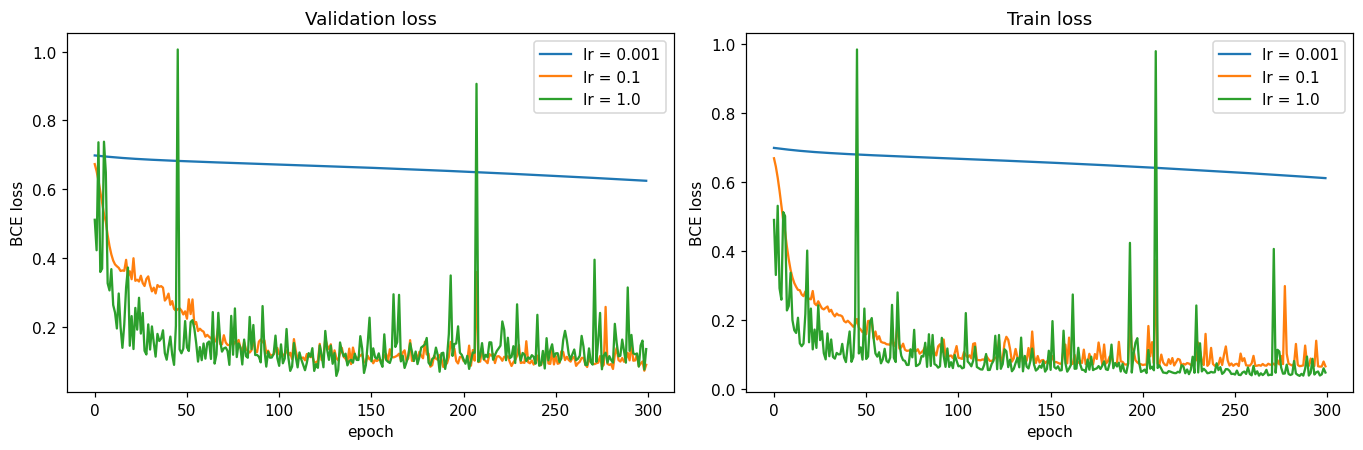

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for lr in [0.001, 0.1, 1.0]:
    h = lr_results[lr]
    axes[0].plot(h["val"], label="lr = %s" % lr)
    axes[1].plot(h["train"], label="lr = %s" % lr)
axes[0].set_title("Validation loss"); axes[1].set_title("Train loss")
for ax in axes:
    ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.legend()
plt.tight_layout(); plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

lr=1.0 fixed:  val end 0.1351 | best val 0.0572
lr=1.0 decay:  val end 0.1095 | best val 0.0870


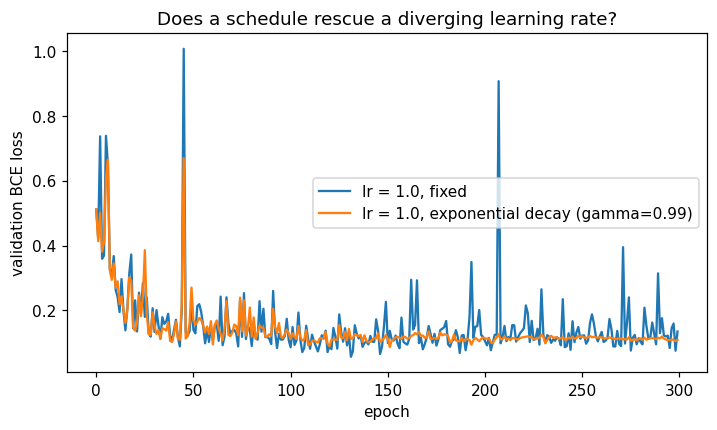

In [8]:
# Counterfactual verification: lr=1.0 with exponential decay
_, h_fixed = train_mlp(32, 16, lr=1.0, epochs=300)
_, h_decay = train_mlp(32, 16, lr=1.0, epochs=300, decay_gamma=0.99)
print("lr=1.0 fixed:  val end %.4f | best val %.4f" % (h_fixed["val"][-1], min(h_fixed["val"])))
print("lr=1.0 decay:  val end %.4f | best val %.4f" % (h_decay["val"][-1], min(h_decay["val"])))
plt.figure(figsize=(7.5, 4))
plt.plot(h_fixed["val"], label="lr = 1.0, fixed")
plt.plot(h_decay["val"], label="lr = 1.0, exponential decay (gamma=0.99)")
plt.xlabel("epoch"); plt.ylabel("validation BCE loss"); plt.legend()
plt.title("Does a schedule rescue a diverging learning rate?")
plt.show()

**Your answer:**

## Challenge

### Task 3: Capacity and Overfitting — Width, Memorization, Regularization

**Experiment (A).** On this easy 2-D task a wide network does not overfit by itself. To make overfitting *visible*, we create something worth memorizing: train on a 100-point subsample of the moons and **flip 40% of the training labels** (the validation labels stay clean). A high-capacity network can memorize the corrupted labels; a small one cannot. Train three widths — hidden layers [4, 4], [64, 64], [256, 256] — with a larger learning rate (0.05) and 3000 epochs so memorization has time to happen.

In [9]:
rng_sub = np.random.RandomState(0)
idx_sub = rng_sub.choice(len(X_train), 100, replace=False)
X_sub, y_sub = X_train[idx_sub], y_train[idx_sub]

rng_flip = np.random.RandomState(7)
flip = rng_flip.rand(len(y_sub)) < 0.40
y_sub_noisy = y_sub.copy()
y_sub_noisy[flip] = 1 - y_sub_noisy[flip]
print("Training set: %d points, %d labels flipped (%.0f%%)" % (len(y_sub), flip.sum(), 100 * flip.mean()))

width_hist = {}
for w in [4, 64, 256]:
    _, h = train_mlp(w, w, lr=0.05, batch_size=16, epochs=3000,
                     Xtr=X_sub, ytr=y_sub_noisy, Xva=X_val, yva=y_val)
    width_hist[w] = h
    best = int(np.argmin(h["val"]))
    print("width %3d | train %.4f | val end %.4f | best val %.4f (epoch %d) | val rise after best: %.4f" %
          (w, h["train"][-1], h["val"][-1], min(h["val"]), best, h["val"][-1] - min(h["val"])))

Training set: 100 points, 33 labels flipped (33%)


width   4 | train 0.6264 | val end 0.4858 | best val 0.4724 (epoch 2990) | val rise after best: 0.0134


width  64 | train 0.4138 | val end 0.6126 | best val 0.3801 (epoch 1561) | val rise after best: 0.2325


width 256 | train 0.3348 | val end 0.9393 | best val 0.3706 (epoch 1045) | val rise after best: 0.5687


**Evidence (C).** Plot train and validation loss for the three widths. The overfitting signature is a validation curve that first improves and then rises while train loss keeps falling.

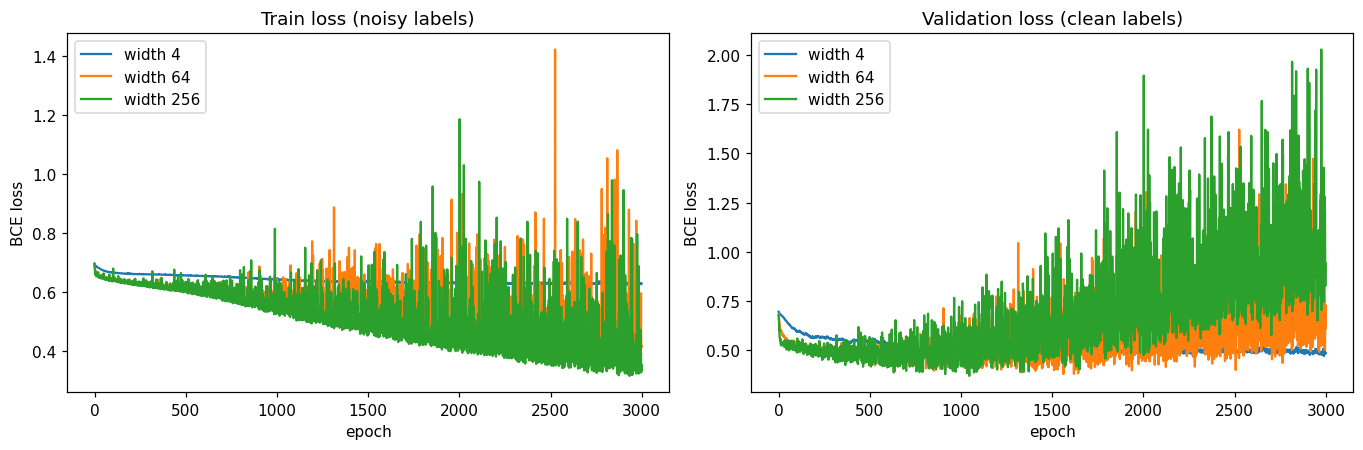

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for w in [4, 64, 256]:
    h = width_hist[w]
    axes[0].plot(h["train"], label="width %d" % w)
    axes[1].plot(h["val"], label="width %d" % w)
axes[0].set_title("Train loss (noisy labels)"); axes[1].set_title("Validation loss (clean labels)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.legend()
plt.tight_layout(); plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

width 256, no regularization : val end 0.9393 (best 0.3706)
width 256, early stopping    : stopped at epoch 1045, val 0.3706
width 256, weight decay 0.01 : val end 0.5509 (best 0.5216)


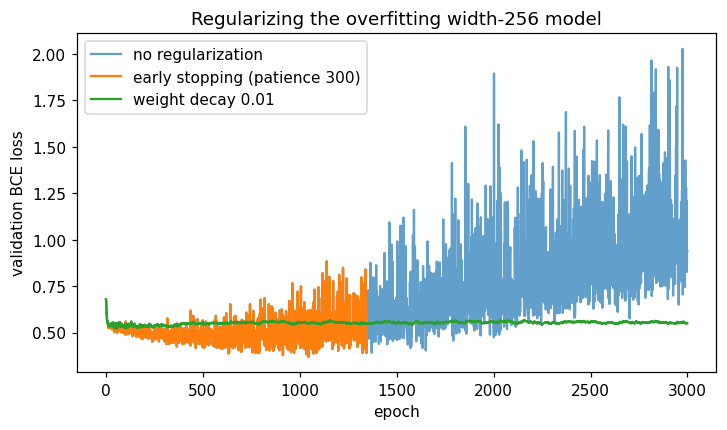

In [11]:
# Counterfactual verification: early stopping and weight decay on width 256
_, h_es = train_mlp(256, 256, lr=0.05, batch_size=16, epochs=3000,
                    Xtr=X_sub, ytr=y_sub_noisy, Xva=X_val, yva=y_val, early_stop_patience=300)
_, h_wd = train_mlp(256, 256, lr=0.05, batch_size=16, epochs=3000, weight_decay=0.01,
                    Xtr=X_sub, ytr=y_sub_noisy, Xva=X_val, yva=y_val)
print("width 256, no regularization : val end %.4f (best %.4f)" % (width_hist[256]["val"][-1], min(width_hist[256]["val"])))
print("width 256, early stopping    : stopped at epoch %s, val %.4f" %
      (h_es.get("stopped_at", "end"), h_es["val"][h_es.get("stopped_at", len(h_es["val"]) - 1)]))
print("width 256, weight decay 0.01 : val end %.4f (best %.4f)" % (h_wd["val"][-1], min(h_wd["val"])))
plt.figure(figsize=(7.5, 4))
plt.plot(width_hist[256]["val"], label="no regularization", alpha=0.7)
plt.plot(h_es["val"], label="early stopping (patience 300)")
plt.plot(h_wd["val"], label="weight decay 0.01")
plt.xlabel("epoch"); plt.ylabel("validation BCE loss"); plt.legend()
plt.title("Regularizing the overfitting width-256 model")
plt.show()

**Your answer:**

### Task 4: Diagnosis — Learning Curves and Permutation Importance

#### Part (a): Bias or Variance? Learning Curves

**Experiment (A).** Fix a validation set of 100 points. Train a somewhat wider MLP ([64, 64], lr=0.05) on training subsets of size 50, 100, 200, and 300, always for the same number of epochs (800). Record the final train and validation loss for each size.

In [12]:
X_pool, X_val_fix, y_pool, y_val_fix = train_test_split(X, y, test_size=0.25, random_state=42)
sizes = [50, 100, 200, 300]
lc = {"train": [], "val": []}
for n in sizes:
    idx = np.random.RandomState(0).choice(len(X_pool), n, replace=False)
    _, h = train_mlp(64, 64, lr=0.05, epochs=800, Xtr=X_pool[idx], ytr=y_pool[idx],
                     Xva=X_val_fix, yva=y_val_fix)
    lc["train"].append(h["train"][-1])
    lc["val"].append(h["val"][-1])
    print("n = %3d | train %.4f | val %.4f | gap %.4f" % (n, h["train"][-1], h["val"][-1], h["train"][-1] - h["val"][-1]))

n =  50 | train 0.0416 | val 0.1737 | gap -0.1321


n = 100 | train 0.0493 | val 0.1997 | gap -0.1504


n = 200 | train 0.0496 | val 0.1286 | gap -0.0790


n = 300 | train 0.0571 | val 0.1056 | gap -0.0485


**Evidence (C).** Plot both errors against training-set size (a learning curve).

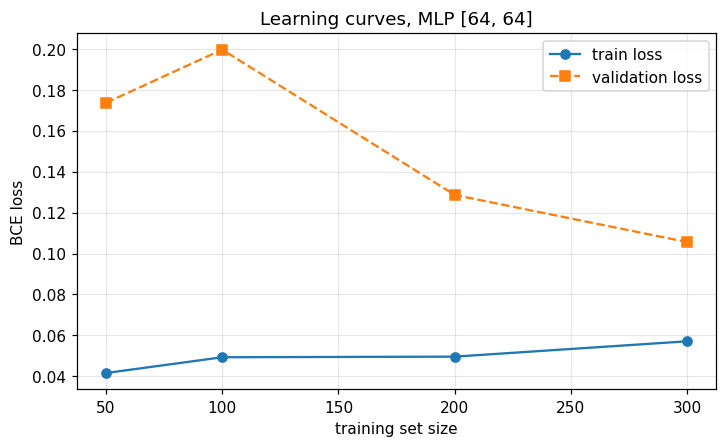

In [13]:
plt.figure(figsize=(7.5, 4.2))
plt.plot(sizes, lc["train"], "o-", label="train loss")
plt.plot(sizes, lc["val"], "s--", label="validation loss")
plt.xlabel("training set size"); plt.ylabel("BCE loss"); plt.title("Learning curves, MLP [64, 64]")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Your answer:**

#### Part (b): Permutation Importance on Breast Cancer

**Experiment (A).** Train a random forest (200 trees) on the breast cancer data, then compute permutation importance with 10 repeats per feature, scoring by negative log-loss on a held-out test set.

In [14]:
Xb, yb = load_breast_cancer(return_X_y=True)
names = load_breast_cancer().feature_names
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(Xb_tr, yb_tr)
print("RF test accuracy: %.4f" % rf.score(Xb_te, yb_te))

pi = permutation_importance(rf, Xb_te, yb_te, n_repeats=10, random_state=42, scoring="neg_log_loss")
imp = pd.DataFrame({"feature": names, "importance": pi.importances_mean, "std": pi.importances_std})
imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
display(imp.head(8))

RF test accuracy: 0.9708


,feature,importance,std
0,worst area,0.079582,0.007519
1,worst perimeter,0.067014,0.007076
2,worst concave points,0.062575,0.009623
3,mean concave points,0.052893,0.009141
4,worst radius,0.051398,0.005599
5,worst concavity,0.045354,0.006691
6,area error,0.042535,0.005035
7,mean concavity,0.029777,0.004663


**Evidence (C).** Plot the top-8 importances with error bars.

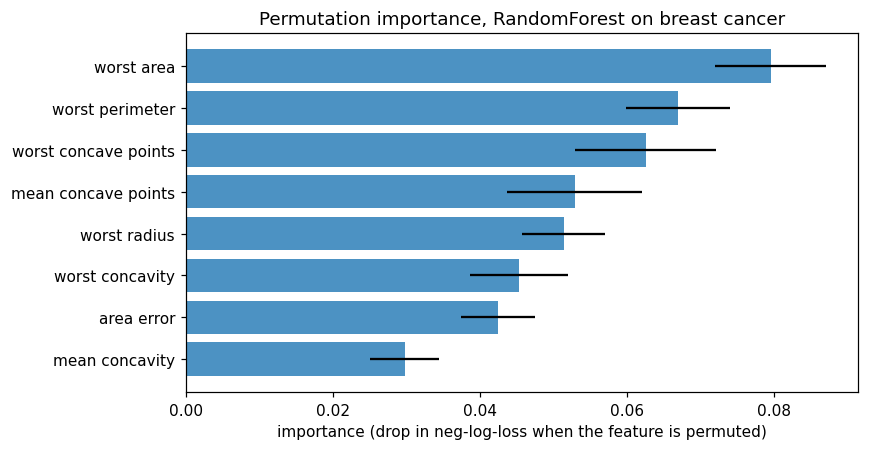

In [15]:
top8 = imp.head(8)
plt.figure(figsize=(8, 4.2))
plt.barh(top8["feature"][::-1], top8["importance"][::-1], xerr=top8["std"][::-1], alpha=0.8)
plt.xlabel("importance (drop in neg-log-loss when the feature is permuted)")
plt.title("Permutation importance, RandomForest on breast cancer")
plt.tight_layout(); plt.show()

**Your answer:**

**Your answer:**

In [16]:
# Counterfactual verification: add a near-duplicate of the top feature
top_feat = imp.iloc[0]["feature"]
top_idx = int(np.where(names == top_feat)[0][0])
dup = Xb[:, top_idx] + np.random.RandomState(1).normal(0, 0.01, len(Xb))
Xb2 = np.column_stack([Xb, dup])
names2 = list(names) + [top_feat + "_dup"]
Xb2_tr, Xb2_te = Xb2[:len(Xb_tr)], Xb2[len(Xb_tr):]

rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(Xb2_tr, yb_tr)
pi2 = permutation_importance(rf2, Xb2_te, yb_te, n_repeats=10, random_state=42, scoring="neg_log_loss")
print("Importance of '%s': before duplicate %.4f -> after duplicate %.4f" %
      (top_feat, imp.iloc[0]["importance"], pi2.importances_mean[top_idx]))
print("Importance of the duplicate feature itself: %.4f" % pi2.importances_mean[-1])

Importance of 'worst area': before duplicate 0.0796 -> after duplicate -0.0006
Importance of the duplicate feature itself: -0.0004


**Your answer:**

---

## Discussion Questions

1. Your teammate trains with lr=1.0, sees the validation loss explode after epoch 200, and concludes "the architecture is wrong". What would you check first?
2. A model achieves train loss 0.01 and validation loss 0.45 on a clean dataset. Is it high-bias or high-variance? What single experiment would confirm it?
3. Permutation importance ranks feature A above feature B. Can you construct a situation where that ranking is misleading? (Hint: think about correlated duplicates.)

## Takeaways

- Loss curves are a diagnostic, not a report card: look at convergence speed, the train/val gap, and *what happens after the best epoch*.
- The learning rate controls the step size of gradient descent: too small → slow, too large → unstable; a decay schedule tames a large rate late in training.
- Capacity is not free: a wide network can memorize corrupted labels. Early stopping and weight decay are two different ways to stop it.
- Learning curves separate bias from variance; permutation importance ranks features but is unreliable for correlated features — a correlated duplicate splits (and hides) the importance.
